## Step 1: Install Required Libraries

In [1]:
!pip install rasterio requests tqdm matplotlib numpy -q

import requests
import os
import json
import tarfile
import glob
import time
import shutil
import warnings
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import rasterio

print('All libraries imported successfully')

All libraries imported successfully


## Step 2: Mount Google Drive & Set Up Shared Folder

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted!')

Mounted at /content/drive
Google Drive mounted!


In [3]:
# Shared Config Block

BASE = '/content/drive/MyDrive/DAT103_Indonesia_Project'

# AOI Bounding Box-(~50 km² inside West Java region)
AOI_BBOX = {
    'min_lon': 107.2831,
    'max_lon': 107.3471,
    'min_lat': -6.7023,
    'max_lat': -6.6383
}

# Shared folder paths
LANDSAT_DIR   = f'{BASE}/data/landsat/'
LULC_DIR      = f'{BASE}/data/lulc/'
PROCESSED_DIR = f'{BASE}/data/processed/'
PATCHES_DIR   = f'{BASE}/data/patches/'
MODELS_DIR    = f'{BASE}/models/'
FIGURES_DIR   = f'{BASE}/figures/'

# Creating all folders(if does not exist)
for d in [LANDSAT_DIR, LULC_DIR, PROCESSED_DIR, PATCHES_DIR, MODELS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Base path : {BASE}')

Base path : /content/drive/MyDrive/DAT103_Indonesia_Project


## Step 3: USGS M2M API Login

In [4]:

USGS_USERNAME = 'harshity'
USGS_TOKEN    = 'jPnuAAohnmuWZyT3!kmXGHQQ!eWYVk3kqB34refboevuRmfjhc1w2zTJ7rNSfYQ8'
M2M_BASE_URL = 'https://m2m.cr.usgs.gov/api/api/json/stable'

def usgs_post(endpoint, payload, headers=None):
    """Send a POST request to the USGS M2M API and return the response data."""
    url  = f'{M2M_BASE_URL}/{endpoint}'
    resp = requests.post(url, json=payload, headers=headers or {})
    data = resp.json()
    if data.get('errorCode'):
        raise RuntimeError(f"USGS API Error [{data['errorCode']}]: {data['errorMessage']}")
    return data

login_resp = usgs_post('login-token', {'username': USGS_USERNAME, 'token': USGS_TOKEN})
API_KEY    = login_resp['data']
HEADERS    = {'X-Auth-Token': API_KEY}

print(f'API Key: {API_KEY[:10]}... (rest hidden for security)')

API Key: eyJjaWQiOj... (rest hidden for security)


## Step 4: Search for Landsat 8/9 Scenes Over Indonesia AOI

- **Filter  :** Cloud cover < 20%
- **Sorted  :** Most recent first

In [5]:
search_payload = {
    'datasetName': 'landsat_ot_c2_l2',
    'maxResults' : 10,
    'sortField'  : 'acquisitionDate',
    'sortDirection': 'DESC',
    'sceneFilter': {
        'spatialFilter': {
            'filterType': 'mbr',
            'lowerLeft' : {'latitude': AOI_BBOX['min_lat'], 'longitude': AOI_BBOX['min_lon']},
            'upperRight': {'latitude': AOI_BBOX['max_lat'], 'longitude': AOI_BBOX['max_lon']}
        },
        'acquisitionFilter': {'start': '2022-01-01', 'end': '2024-12-31'},
        'cloudCoverFilter' : {'min': 0, 'max': 20}
    }
}

search_resp = usgs_post('scene-search', search_payload, HEADERS)
scenes = search_resp['data']['results']

print(f'Found {len(scenes)} scene(s) matching criteria:\n')
print(f'{"#":<4} {"Scene ID":<45} {"Date":<15} {"Cloud%":<10} Satellite')
print('-' * 85)
for idx, sc in enumerate(scenes):
    sat = 'Landsat 9' if sc['entityId'].startswith('LC09') else 'Landsat 8'
    date = sc.get('publishDate', 'N/A')
    cloud = sc.get('cloudCover', 0)

    # If cloudCover is returned as a string, converting it to float for the :.1f formatting
    try:
        cloud = float(cloud)
    except:
        cloud = 0.0

    print(f"{idx:<4} {sc['entityId']:<45} {date:<15} {cloud:<10.1f} {sat}")

Found 10 scene(s) matching criteria:

#    Scene ID                                      Date            Cloud%     Satellite
-------------------------------------------------------------------------------------
0    LC81220642024300LGN00                         2024-10-29 18:10:33-05 9.0        Landsat 8
1    LC91220642024292LGN00                         2024-10-22 04:04:00-05 11.0       Landsat 8
2    LC91220652024292LGN00                         2024-10-22 04:02:04-05 14.0       Landsat 8
3    LC81220642024284LGN00                         2024-10-15 14:49:44-05 11.0       Landsat 8
4    LC91220642024260LGN00                         2024-09-17 07:58:29-05 13.0       Landsat 8
5    LC91220652024260LGN00                         2024-09-17 07:57:36-05 4.0        Landsat 8
6    LC81220642024252LGN00                         2024-09-14 00:03:17-05 20.0       Landsat 8
7    LC91220642024244LGN00                         2024-09-01 06:50:08-05 0.0        Landsat 8
8    LC91220652024244LGN00  

## Step 5: Selecting the Best Scene

In [6]:
SCENE_INDEX    = 3

selected_scene = scenes[SCENE_INDEX]
SCENE_ID       = selected_scene['entityId']
DATASET_NAME   = 'landsat_ot_c2_l2'
satellite      = 'Landsat 9' if SCENE_ID.startswith('LC09') else 'Landsat 8'

print('=' * 60)
print('SELECTED SCENE')
print('=' * 60)
print(f'  Scene ID    : {SCENE_ID}')
print(f'  Satellite   : {satellite}')
print(f'  Date        : {selected_scene.get('publishDate', 'N/A')}')
print(f'  Cloud Cover : {selected_scene["cloudCover"]}%')
print('=' * 60)

SELECTED SCENE
  Scene ID    : LC81220642024284LGN00
  Satellite   : Landsat 8
  Date        : 2024-10-15 14:49:44-05
  Cloud Cover : 11%


## Step 6: Get the Download Product ID

In [7]:
options_resp = usgs_post('download-options', {
    'datasetName': DATASET_NAME,
    'entityIds'  : [SCENE_ID]
}, HEADERS)

products  = options_resp['data']
available = [p for p in products
             if p.get('available') is True or p.get('downloadSystem') == 'dds']

print(f'Available download products for {SCENE_ID}:\n')
for i, p in enumerate(available):
    print(f"  [{i}] {p.get('productName', 'Unknown')}")
    print(f"       ID   : {p.get('id', '?')}")
    print(f"       Size : {p.get('filesize', 'unknown')} bytes\n")

# Auto-select the bundle product (preferred: contains all bands)
bundle = None
for p in available:
    name = p.get('productName', '').lower()
    if 'bundle' in name or 'l2sp' in name:
        bundle = p
        break
if bundle is None and available:
    bundle = available[0]   # fallback to first available

PRODUCT_ID = bundle['id']
print(f'\nSelected product: {bundle.get("productName", "?")} (ID: {PRODUCT_ID})')

Available download products for LC81220642024284LGN00:

  [0] Landsat Collection 2 Level-2 Product Bundle
       ID   : 5e83d14fec7cae84
       Size : 811649070 bytes

  [1] Landsat Collection 2 Level-2 Band File
       ID   : 6448198cc7b442a4
       Size : 0 bytes

  [2] Landsat Collection 2 Level-2 Band File
       ID   : 6448198c62023764
       Size : 0 bytes


Selected product: Landsat Collection 2 Level-2 Product Bundle (ID: 5e83d14fec7cae84)


## Step 7: Request & Download the Landsat Scene

In [8]:
DOWNLOAD_LABEL = f'dat103_{SCENE_ID[:15]}'

# Step 7a: Submiting the download request
req_resp = usgs_post('download-request', {
    'downloads': [{'entityId': SCENE_ID, 'productId': PRODUCT_ID}],
    'label': DOWNLOAD_LABEL
}, HEADERS)

DOWNLOAD_URL = None

# Checking if the URL is already available immediately
avail_now = req_resp['data'].get('availableDownloads', [])
if avail_now:
    DOWNLOAD_URL = avail_now[0]['url']
    print('URL was ready immediately!')

# Step 7b: Only poll if the URL wasn't in the first response
if not DOWNLOAD_URL:
    for attempt in range(20):
        ret = usgs_post('download-retrieve', {'label': DOWNLOAD_LABEL}, HEADERS)
        avail = ret['data'].get('available', [])
        if avail:
            DOWNLOAD_URL = avail[0]['url']
            print(f'\n Download URL is ready! (Attempt {attempt+1})')
            break
        print(f'   Attempt {attempt+1}/20 — still preparing... (waiting 15s)')
        time.sleep(15)

if not DOWNLOAD_URL:
    raise RuntimeError('URL not ready after 5 minutes. Re-run this cell.')

print(f'URL: {DOWNLOAD_URL[:70]}...')

URL was ready immediately!
URL: https://landsatlook.usgs.gov/gen-bundle?landsat_product_id=LC08_L2SP_1...


In [9]:
# Step 7c: Downloading the .tar file with a progress bar
LOCAL_TAR = f'/content/{SCENE_ID}.tar'
print(f'Downloading in {LOCAL_TAR}')

with requests.get(DOWNLOAD_URL, stream=True, timeout=600) as r:
    r.raise_for_status()
    total = int(r.headers.get('content-length', 0))
    with open(LOCAL_TAR, 'wb') as f, tqdm(total=total, unit='B',
                                           unit_scale=True, ncols=80) as bar:
        for chunk in r.iter_content(1024 * 1024):  # 1 MB chunks
            f.write(chunk)
            bar.update(len(chunk))

size_mb = os.path.getsize(LOCAL_TAR) / 1e6
print(f'\n Download complete — {size_mb:.1f} MB')

100%|████████████████████████████████████████| 812M/812M [00:23<00:00, 35.0MB/s]


 Download complete — 811.9 MB


## Step 8: Extract Band Files & Copy to Google Drive

In [10]:
# Extracting the .tar archive to local Colab storage
LOCAL_EXT = f'/content/{SCENE_ID}_extracted/'
os.makedirs(LOCAL_EXT, exist_ok=True)

print('Extracting archive...')
with tarfile.open(LOCAL_TAR) as tar:
    tar.extractall(LOCAL_EXT)

all_files = sorted(os.listdir(LOCAL_EXT))
print(f'\nExtracted {len(all_files)} files:')
for fn in all_files:
    mb = os.path.getsize(os.path.join(LOCAL_EXT, fn)) / 1e6
    print(f'  {fn}  ({mb:.1f} MB)')

/tmp/ipykernel_4507/913762536.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(LOCAL_EXT)


Extracting archive...

Extracted 27 files:
  LC08_L2SP_122064_20241010_20241015_02_T1_ANG.txt  (0.1 MB)
  LC08_L2SP_122064_20241010_20241015_02_T1_MTL.json  (0.0 MB)
  LC08_L2SP_122064_20241010_20241015_02_T1_MTL.txt  (0.0 MB)
  LC08_L2SP_122064_20241010_20241015_02_T1_MTL.xml  (0.0 MB)
  LC08_L2SP_122064_20241010_20241015_02_T1_QA_PIXEL.TIF  (2.5 MB)
  LC08_L2SP_122064_20241010_20241015_02_T1_QA_RADSAT.TIF  (0.2 MB)
  LC08_L2SP_122064_20241010_20241015_02_T1_SR_B1.TIF  (82.8 MB)
  LC08_L2SP_122064_20241010_20241015_02_T1_SR_B2.TIF  (82.6 MB)
  LC08_L2SP_122064_20241010_20241015_02_T1_SR_B3.TIF  (82.1 MB)
  LC08_L2SP_122064_20241010_20241015_02_T1_SR_B4.TIF  (83.1 MB)
  LC08_L2SP_122064_20241010_20241015_02_T1_SR_B5.TIF  (84.2 MB)
  LC08_L2SP_122064_20241010_20241015_02_T1_SR_B6.TIF  (82.2 MB)
  LC08_L2SP_122064_20241010_20241015_02_T1_SR_B7.TIF  (80.2 MB)
  LC08_L2SP_122064_20241010_20241015_02_T1_SR_QA_AEROSOL.TIF  (3.8 MB)
  LC08_L2SP_122064_20241010_20241015_02_T1_SR_stac.json  (0.

In [11]:
import glob
import os
import shutil
import rasterio
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds

REQUIRED_BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7']
band_paths = {}

print(f'Clipping and saving 50km² AOI to Google Drive\n')

for band in REQUIRED_BANDS:
    # Find the local extracted file
    hits = (glob.glob(f'{LOCAL_EXT}/*_SR_{band}.TIF') +
            glob.glob(f'{LOCAL_EXT}/*_{band}.TIF'))

    if not hits:
        print(f'  Band {band} — NOT FOUND!')
        continue

    src_path = hits[0]
    fn = os.path.basename(src_path)
    dst_path = os.path.join(LANDSAT_DIR, fn)

    # --- CLIPPING LOGIC ---
    with rasterio.open(src_path) as src:
        # 1. Convert Lat/Lon bounds (Degrees) to Image Coordinates (Meters)
        left, bottom, right, top = transform_bounds(
            'EPSG:4326',
            src.crs,
            AOI_BBOX['min_lon'], AOI_BBOX['min_lat'],
            AOI_BBOX['max_lon'], AOI_BBOX['max_lat']
        )

        # 2. Define the window using the transformed bounds and the correct src.transform
        window = from_bounds(left, bottom, right, top, transform=src.transform)

        # 3. Read only the data within that window
        clip_data = src.read(1, window=window)

        # 4. Update the metadata for the small file
        out_profile = src.profile.copy()
        out_profile.update({
            'height': clip_data.shape[0],
            'width': clip_data.shape[1],
            'transform': src.window_transform(window)
        })

        # 5. Save the clipped version directly to Google Drive
        with rasterio.open(dst_path, 'w', **out_profile) as dst_file:
            dst_file.write(clip_data, 1)

    band_paths[band] = dst_path
    print(f'  Band {band}: {fn} (Clipped & Saved)')

# Copy metadata text file
for mtl in glob.glob(f'{LOCAL_EXT}/*_MTL.txt'):
    shutil.copy2(mtl, os.path.join(LANDSAT_DIR, os.path.basename(mtl)))
    print(f'  Metadata: {os.path.basename(mtl)} copied.')

print(f'\n Clipped images are now in: {LANDSAT_DIR}')

Clipping and saving 50km² AOI to Google Drive

  Band B2: LC08_L2SP_122064_20241010_20241015_02_T1_SR_B2.TIF (Clipped & Saved)
  Band B3: LC08_L2SP_122064_20241010_20241015_02_T1_SR_B3.TIF (Clipped & Saved)
  Band B4: LC08_L2SP_122064_20241010_20241015_02_T1_SR_B4.TIF (Clipped & Saved)
  Band B5: LC08_L2SP_122064_20241010_20241015_02_T1_SR_B5.TIF (Clipped & Saved)
  Band B6: LC08_L2SP_122064_20241010_20241015_02_T1_SR_B6.TIF (Clipped & Saved)
  Band B7: LC08_L2SP_122064_20241010_20241015_02_T1_SR_B7.TIF (Clipped & Saved)
  Metadata: LC08_L2SP_122064_20241010_20241015_02_T1_MTL.txt copied.

 Clipped images are now in: /content/drive/MyDrive/DAT103_Indonesia_Project/data/landsat/


## Step 9: Display True Color Composite (RGB = Band 4, 3, 2)

In [12]:
from rasterio.windows import from_bounds

def read_band_scaled(path):
    """Reads the pre-clipped file and scales it."""
    with rasterio.open(path) as src:
        raw = src.read(1).astype(np.float32)
        profile = src.profile

    scaled = raw * 0.0000275 - 0.2
    scaled[raw == 0] = np.nan
    return scaled, profile

def pct_norm(band, lo=2, hi=98):
    """Percentile stretch for better visual display."""
    valid = band[~np.isnan(band)]
    if valid.size == 0: return band
    vlo, vhi = np.percentile(valid, [lo, hi])
    out = np.clip((band - vlo) / (vhi - vlo + 1e-8), 0, 1)
    out[np.isnan(band)] = 0
    return out

# --- Executeing the processing ---
red, profile = read_band_scaled(band_paths['B4'])
green, _     = read_band_scaled(band_paths['B3'])
blue, _      = read_band_scaled(band_paths['B2'])

print(f"Image size: {red.shape[0]} rows × {red.shape[1]} cols")

Image size: 237 rows × 237 cols


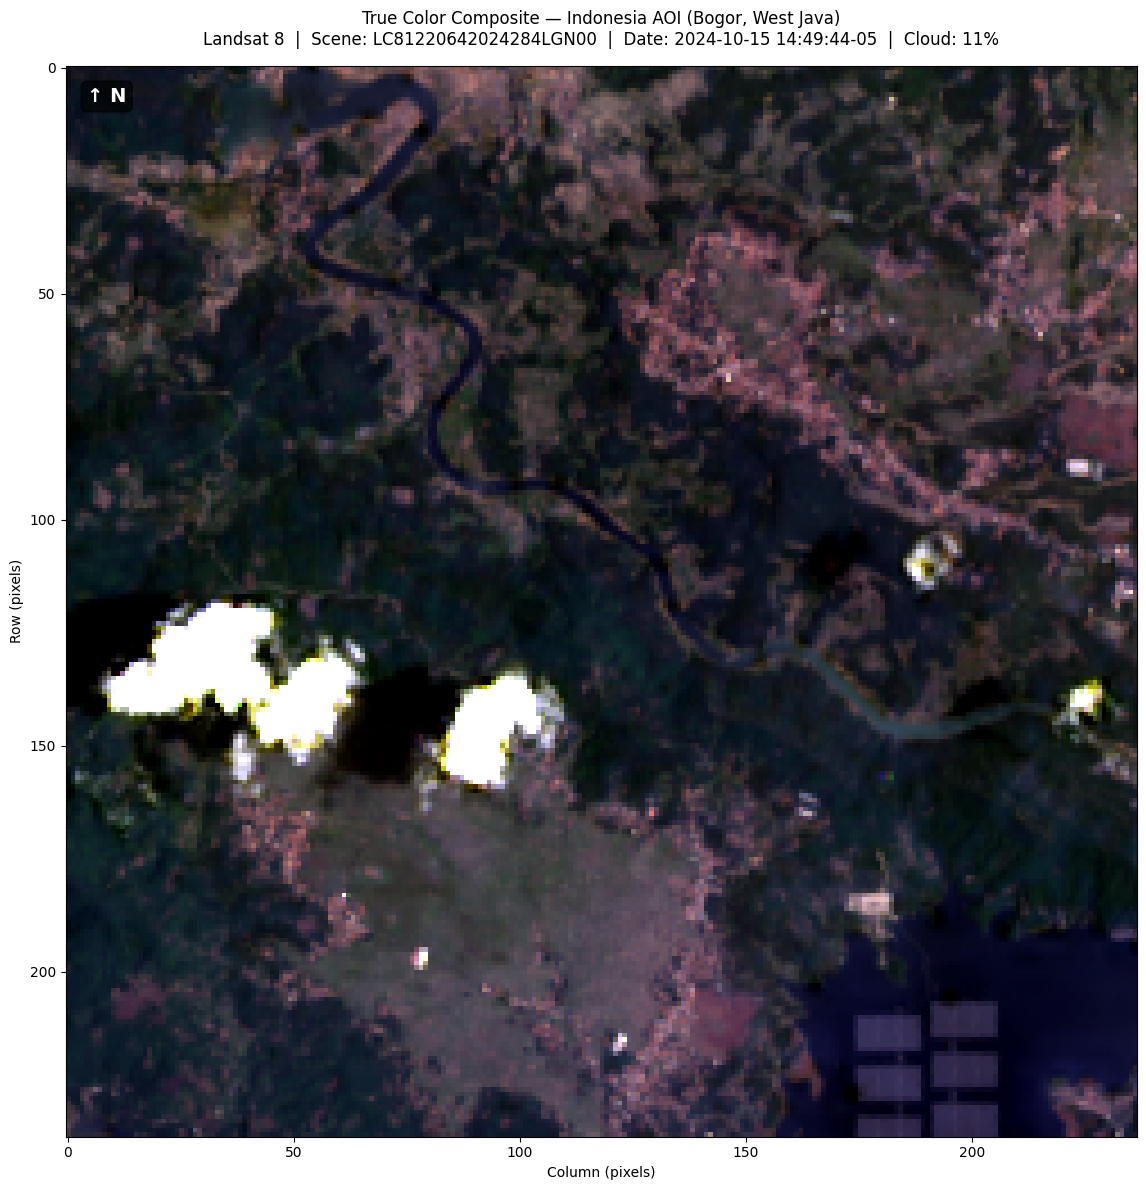

Saved → /content/drive/MyDrive/DAT103_Indonesia_Project/figures//true_color.png


In [13]:
# Creating and displaying the True Color Composite
rgb = np.dstack([pct_norm(red), pct_norm(green), pct_norm(blue)])

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(rgb)
ax.set_title(
    f'True Color Composite — Indonesia AOI (Bogor, West Java)\n'
    f'{satellite}  |  Scene: {SCENE_ID}  |  '
    f'Date: {selected_scene.get("publishDate", "N/A")}  |  ' # <--- Fixed key
    f'Cloud: {selected_scene["cloudCover"]}%',
    fontsize=12, pad=15)
ax.set_xlabel('Column (pixels)', fontsize=10)
ax.set_ylabel('Row (pixels)', fontsize=10)

ax.text(0.02, 0.98, '↑ N', transform=ax.transAxes,
        fontsize=14, color='white', fontweight='bold', va='top',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.6))

plt.tight_layout()

fig_path = f'{FIGURES_DIR}/true_color.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')

## Step 10: All 6 Bands Overview (for Report)

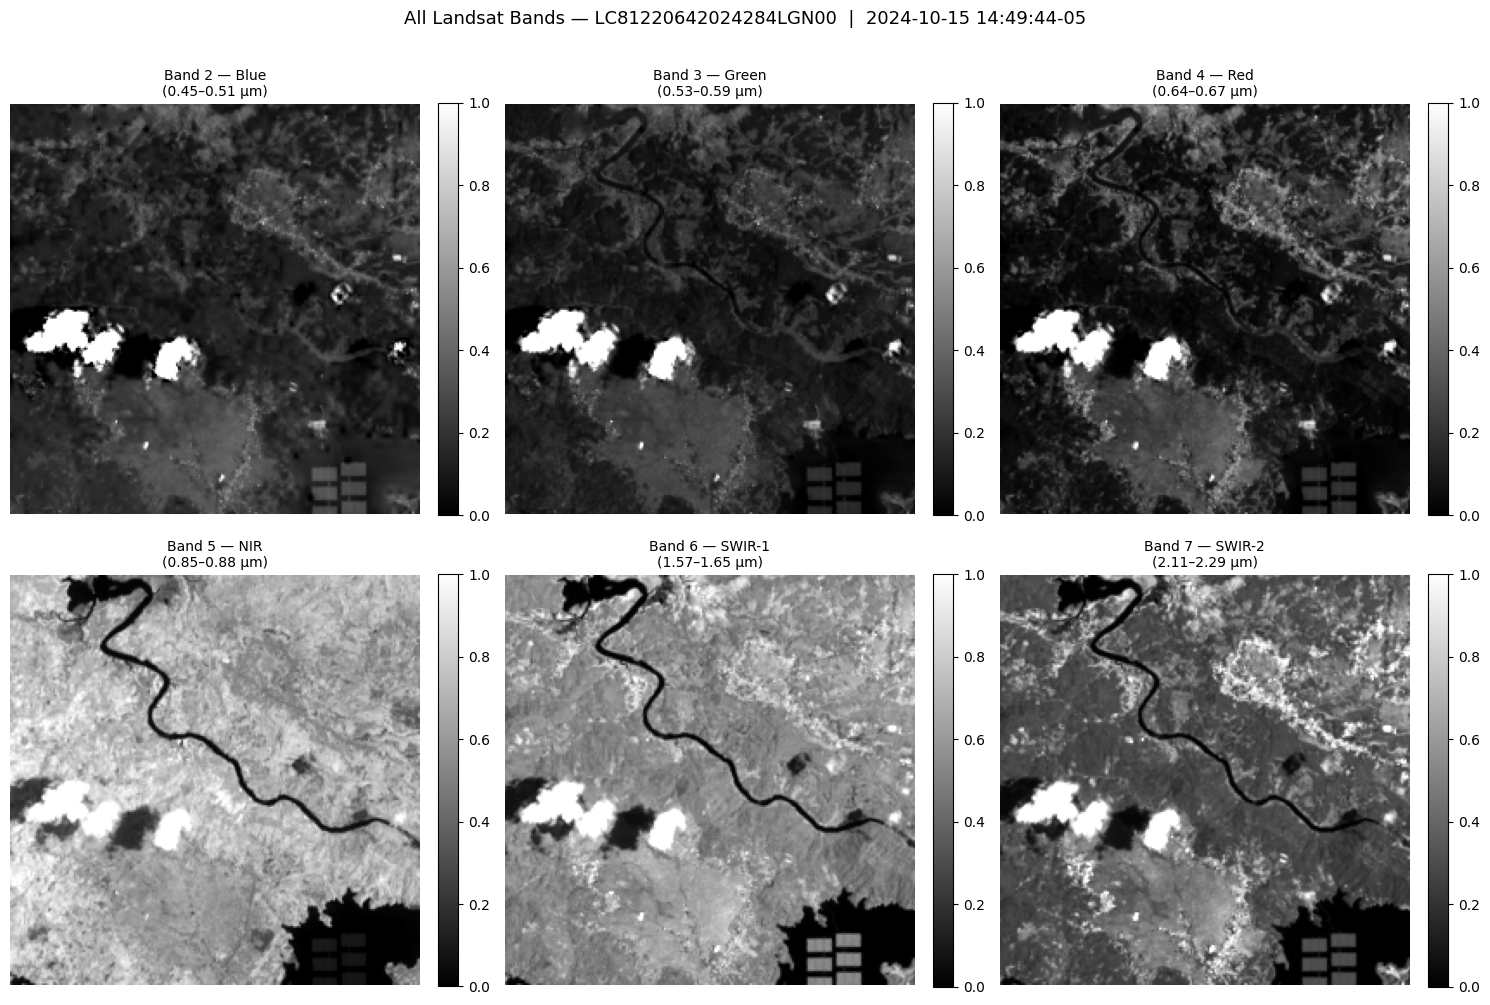

Saved → /content/drive/MyDrive/DAT103_Indonesia_Project/figures//all_bands_overview.png


In [14]:
BAND_INFO = {
    'B2': 'Band 2 — Blue\n(0.45–0.51 µm)',
    'B3': 'Band 3 — Green\n(0.53–0.59 µm)',
    'B4': 'Band 4 — Red\n(0.64–0.67 µm)',
    'B5': 'Band 5 — NIR\n(0.85–0.88 µm)',
    'B6': 'Band 6 — SWIR-1\n(1.57–1.65 µm)',
    'B7': 'Band 7 — SWIR-2\n(2.11–2.29 µm)',
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (band, label) in zip(axes.flatten(), BAND_INFO.items()):
    data, _ = read_band_scaled(band_paths[band])
    im = ax.imshow(pct_norm(data), cmap='gray')
    ax.set_title(label, fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(
    f'All Landsat Bands — {SCENE_ID}  |  {selected_scene.get("publishDate", "N/A")}', # <--- Fixed key
    fontsize=13, y=1.01)
plt.tight_layout()

bfig = f'{FIGURES_DIR}/all_bands_overview.png'
plt.savefig(bfig, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved → {bfig}')

## Step 11: Saving Scene Metadata JSON & Logout

In [15]:
metadata = {
    'scene_id'         : SCENE_ID,
    'satellite'        : satellite,
    'acquisition_date' : selected_scene.get('publishDate', 'N/A'),
    'cloud_cover_pct'  : selected_scene['cloudCover'],
    'dataset'          : DATASET_NAME,
    'aoi_bbox'         : AOI_BBOX,
    'bands_downloaded' : REQUIRED_BANDS,
    'image_shape'      : list(red.shape),
    'crs'              : str(profile['crs']),
    'transform'        : str(profile['transform']),
    'band_files'       : {b: os.path.basename(p) for b, p in band_paths.items()}
}

meta_path = f'{LANDSAT_DIR}/scene_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved scene metadata:')
print(json.dumps(metadata, indent=2))

# Logout from USGS
usgs_post('logout', {}, HEADERS)
print(f'Metadata saved at: {meta_path}')

Saved scene metadata:
{
  "scene_id": "LC81220642024284LGN00",
  "satellite": "Landsat 8",
  "acquisition_date": "2024-10-15 14:49:44-05",
  "cloud_cover_pct": 11,
  "dataset": "landsat_ot_c2_l2",
  "aoi_bbox": {
    "min_lon": 107.2831,
    "max_lon": 107.3471,
    "min_lat": -6.7023,
    "max_lat": -6.6383
  },
  "bands_downloaded": [
    "B2",
    "B3",
    "B4",
    "B5",
    "B6",
    "B7"
  ],
  "image_shape": [
    237,
    237
  ],
  "crs": "EPSG:32648",
  "transform": "| 30.00, 0.00, 752392.59|\n| 0.00,-30.00,-734346.11|\n| 0.00, 0.00, 1.00|",
  "band_files": {
    "B2": "LC08_L2SP_122064_20241010_20241015_02_T1_SR_B2.TIF",
    "B3": "LC08_L2SP_122064_20241010_20241015_02_T1_SR_B3.TIF",
    "B4": "LC08_L2SP_122064_20241010_20241015_02_T1_SR_B4.TIF",
    "B5": "LC08_L2SP_122064_20241010_20241015_02_T1_SR_B5.TIF",
    "B6": "LC08_L2SP_122064_20241010_20241015_02_T1_SR_B6.TIF",
    "B7": "LC08_L2SP_122064_20241010_20241015_02_T1_SR_B7.TIF"
  }
}
Metadata saved at: /content/drive/